<a href="https://colab.research.google.com/github/mclarasv/programacion_demo1/blob/main/Meliza_Clara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, trapezoid

x = np.array([0, 2, 3, 6, 7])
y = np.array([0.120, 0.153, 0.170, 0.225, 0.260])

n = len(x)


In [2]:
area_manual = 0
for i in range(n - 1):
    area_manual += (x[i + 1] - x[i]) * (y[i] + y[i + 1]) / 2

promedio_manual = area_manual / (x[-1] - x[0])

print("Área (trapecio manual) =", area_manual)
print("Promedio manual (trapecio) =", promedio_manual)


Área (trapecio manual) = 1.2695
Promedio manual (trapecio) = 0.18135714285714286


In [3]:
area_scipy_trap = trapezoid(y, x=x)
promedio_scipy_trap = area_scipy_trap / (x[-1] - x[0])
error_trap = abs(promedio_manual - promedio_scipy_trap) / promedio_scipy_trap * 100

area_scipy_simpson = simpson(y, x=x)
promedio_scipy_simpson = area_scipy_simpson / (x[-1] - x[0])
error_simpson = abs(promedio_manual - promedio_scipy_simpson) / promedio_scipy_simpson * 100

print("Área (scipy trapezoid) =", area_scipy_trap)
print("Promedio scipy (trapecio) =", promedio_scipy_trap)
print("Error del promedio [%] =", error_trap)

print("\nÁrea (scipy simpson) =", area_scipy_simpson)
print("Promedio scipy (Simpson) =", promedio_scipy_simpson)
print("Error del promedio [%] =", error_simpson)


Área (scipy trapezoid) = 1.2695
Promedio scipy (trapecio) = 0.18135714285714286
Error del promedio [%] = 0.0

Área (scipy simpson) = 1.2498055555555556
Promedio scipy (Simpson) = 0.1785436507936508
Error del promedio [%] = 1.5758006801057842


In [4]:
dydx_manual = np.zeros(n)

dydx_manual[0] = (y[1] - y[0]) / (x[1] - x[0])

for i in range(1, n - 1):
    dydx_manual[i] = (y[i + 1] - y[i - 1]) / (x[i + 1] - x[i - 1])

dydx_manual[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])

print("Derivada (diferencias finitas, método de clase) =", dydx_manual)


Derivada (diferencias finitas, método de clase) = [0.0165     0.01666667 0.018      0.0225     0.035     ]


Derivada (numpy.gradient) = [0.0165     0.01683333 0.01733333 0.03083333 0.035     ]
Error local en cada punto = [0.         0.00016667 0.00066667 0.00833333 0.        ]
Error global (promedio de errores locales) = 0.001833333333333334


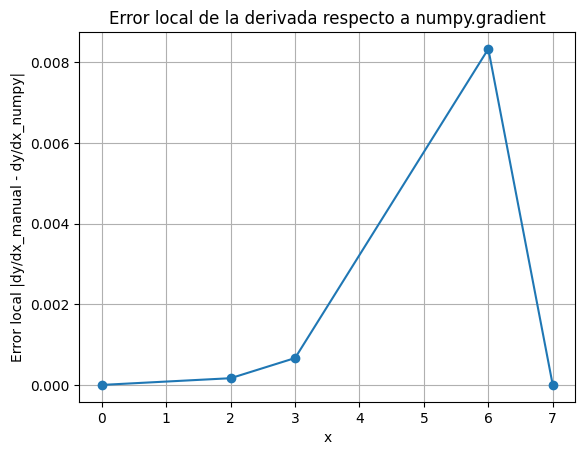

In [5]:
dydx_numpy = np.gradient(y, x)

error_local = abs(dydx_manual - dydx_numpy)
error_global = np.mean(error_local)

print("Derivada (numpy.gradient) =", dydx_numpy)
print("Error local en cada punto =", error_local)
print("Error global (promedio de errores locales) =", error_global)

plt.figure()
plt.plot(x, error_local, 'o-')
plt.xlabel("x")
plt.ylabel("Error local |dy/dx_manual - dy/dx_numpy|")
plt.title("Error local de la derivada respecto a numpy.gradient")
plt.grid(True)
plt.show()
